<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/projects/project_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Analítica de Recursos Humanos: Determinantes Salariales y Modelación de Compensaciones


## Contexto y Objetivo

Una firma multinacional de consultoría ha sido contratada por **TalentCo**, empresa con operaciones en múltiples regiones y departamentos, para analizar su estructura de compensaciones. El equipo de Recursos Humanos sospecha que los salarios no están siendo asignados de manera consistente: algunos empleados se sienten subpagados en relación con pares de experiencia similar, mientras que otros en el mismo departamento perciben montos significativamente distintos según su región o nivel educacional.

Su rol es actuar como **Analista de Datos** en la firma consultora. Utilizará Python, pruebas de hipótesis estadísticas y regresión lineal para identificar los principales determinantes del salario de los empleados, y entregará recomendaciones basadas en datos a la dirección de TalentCo.

Al finalizar este proyecto, usted será capaz de:

- Realizar análisis exploratorio de datos (EDA) sobre datos de Recursos Humanos.
- Aplicar pruebas de hipótesis para validar supuestos de negocio.
- Manejar variables categóricas mediante técnicas de codificación.
- Construir y evaluar modelos de regresión con OLS y scikit-learn.
- Verificar los supuestos de regresión (multicolinealidad, normalidad, homocedasticidad).
- Comunicar resultados en un informe orientado al negocio.



## Conjunto de Datos: `employee_compensation.csv`

Disponible en la sección de materiales del curso. Contiene registros de **1.500 empleados** distribuidos en distintos departamentos, regiones y niveles de cargo.

| Variable | Tipo | Descripción |
|---|---|---|
| `Salary` | Numérica (USD/año) | Salario bruto anual — **variable objetivo** |
| `Years_Experience` | Numérica | Total de años de experiencia profesional |
| `Age` | Numérica | Edad del empleado |
| `Performance_Score` | Numérica (1.0–5.0) | Calificación de desempeño anual más reciente |
| `Education_Level` | Categórica | Bachelor, Master, PhD |
| `Department` | Categórica | Engineering, Sales, Marketing, HR, Finance |
| `Region` | Categórica | North, South, East, West |
| `Job_Level` | Categórica | Junior, Mid, Senior |
| `Gender` | Categórica | Male, Female |




> **Nota sobre la generación del dataset:** Este conjunto de datos puede generarse sintéticamente con `numpy` y `pandas`, utilizando distribuciones salariales realistas por departamento y nivel de cargo. Se incluirá un script de generación (`generate_dataset.py`) junto al dataset.

In [ ]:
import pandas as pd

# cargar datos
path = '/content/employee_compensation.csv'
df = pd.read_csv(path, sep="," )

df.head()

,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female


---
## ✅ **Parte 1: Análisis Exploratorio de Datos (EDA)** ✅
---


1. Cargue el dataset en un DataFrame de pandas.
2. Muestre las primeras 10 filas e inspeccione los tipos de datos.
3. Verifique valores faltantes y duplicados; reporte los hallazgos.
4. Calcule estadísticas descriptivas (media, mediana, desviación estándar, mínimo, máximo) para todas las variables numéricas.
5. Elabore al menos **tres** de las siguientes visualizaciones:
   - Histograma del salario.
   - Diagrama de caja (*box plot*) del salario por nivel de cargo.
   - Diagrama de dispersión de años de experiencia vs. salario.
   - Gráfico de barras del salario promedio por departamento.
   - Mapa de calor de correlaciones entre variables numéricas.



**1.** Cargue el dataset en un DataFrame de pandas.

**2.** Muestre las primeras 10 filas e inspeccione los tipos de datos.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Primeras 10 filas del DataFrame:")
display(df.head(10))

Primeras 10 filas del DataFrame:


,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female
5,81246.0,4.0,21.0,2.8,Bachelor,Engineering,West,Junior,Male
6,71494.0,4.0,23.0,2.4,Bachelor,Engineering,South,Junior,Male
7,78189.0,3.0,21.0,3.5,Master,Finance,East,Junior,NaN
8,67204.0,0.0,21.0,3.5,Master,Marketing,East,Junior,Female
9,59776.0,4.0,24.0,NaN,Bachelor,HR,East,Junior,Female


**3.** Verifique valores faltantes y duplicados; reporte los hallazgos.

In [ ]:
print("\nTipos de datos e información del DataFrame:")
df.info()

print("\nValores faltantes por columna:")
display(df.isnull().sum())

print(f"\nNúmero de filas duplicadas: {df.duplicated().sum()}\n")


Tipos de datos e información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Salary             9897 non-null   float64
 1   Years_Experience   9695 non-null   float64
 2   Age                9797 non-null   float64
 3   Performance_Score  9497 non-null   float64
 4   Education_Level    9594 non-null   object 
 5   Department         9795 non-null   object 
 6   Region             9699 non-null   object 
 7   Job_Level          10100 non-null  object 
 8   Gender             9599 non-null   object 
dtypes: float64(4), object(5)
memory usage: 710.3+ KB

Valores faltantes por columna:


,0
Salary,203
Years_Experience,405
Age,303
Performance_Score,603
Education_Level,506
Department,305
Region,401
Job_Level,0
Gender,501



Número de filas duplicadas: 97



**4.** Calcule estadísticas descriptivas (media, mediana, desviación estándar, mínimo, máximo) para todas las variables numéricas.

In [ ]:
print("Estadísticas descriptivas para variables numéricas:")
display(df.describe())

Estadísticas descriptivas para variables numéricas:


,Salary,Years_Experience,Age,Performance_Score
count,9897.000000,9695.000000,9797.000000,9497.000000
mean,95728.604527,6.817019,29.460855,3.028188
std,30599.451256,5.688109,6.845404,1.809318
min,5342.000000,-10.000000,1.000000,-1.000000
25%,76834.000000,2.000000,25.000000,2.000000
50%,91701.000000,6.000000,29.000000,3.000000
75%,111908.000000,10.000000,34.000000,4.000000
max,394249.000000,78.000000,119.000000,99.000000


**5. Elabore al menos tres de las siguientes visualizaciones:**


*   HISTOGRAMA DEL SALARIO




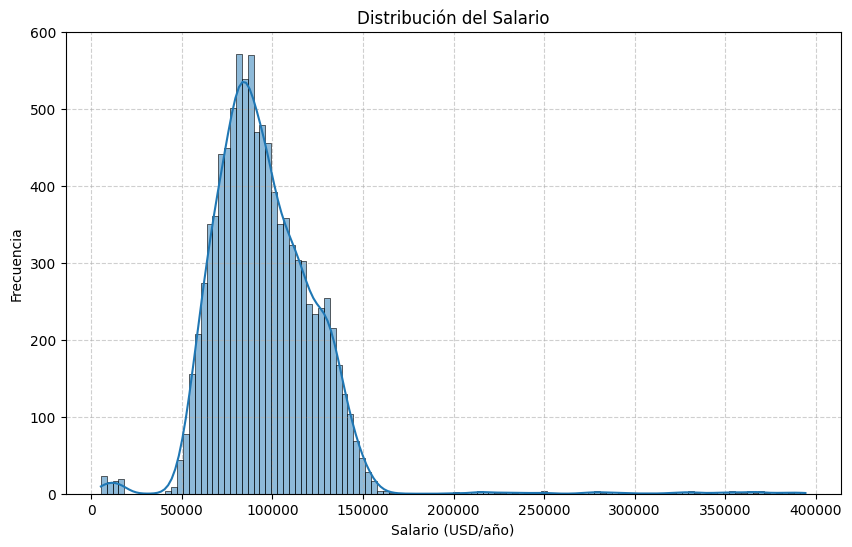

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary'].dropna(), kde=True)
plt.title('Distribución del Salario')
plt.xlabel('Salario (USD/año)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



*   DIAGRAMA DE CAJA (BOX PLOT) DEL SALARIO POR NIVEL DE CARGO.



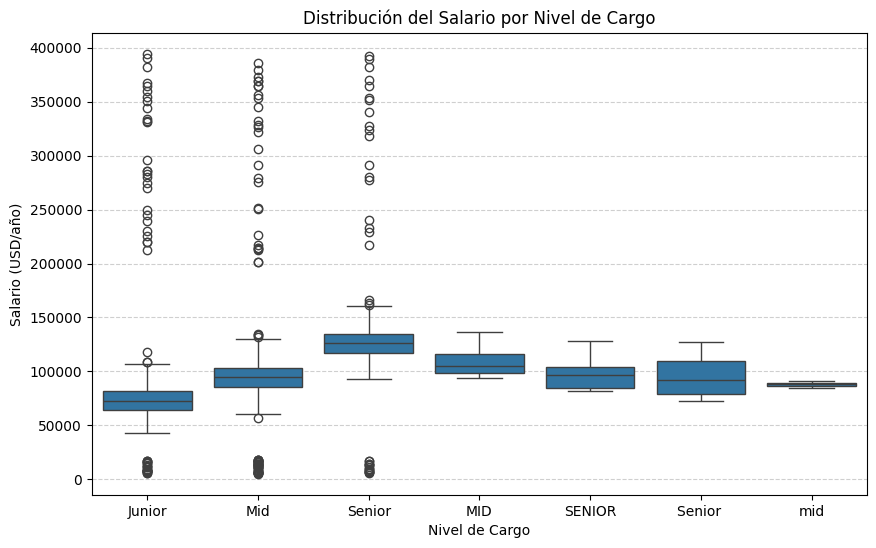

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Job_Level', y='Salary', data=df.dropna(subset=['Job_Level', 'Salary']))
plt.title('Distribución del Salario por Nivel de Cargo')
plt.xlabel('Nivel de Cargo')
plt.ylabel('Salario (USD/año)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()



*   Diagrama de dispersión de años de experiencia vs. salario.



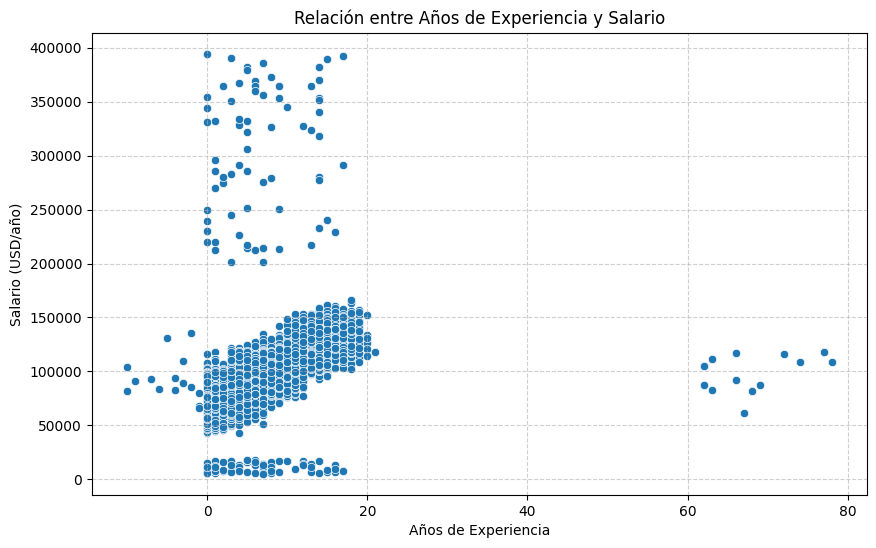

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Years_Experience', y='Salary', data=df.dropna(subset=['Years_Experience', 'Salary']))
plt.title('Relación entre Años de Experiencia y Salario')
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario (USD/año)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



*   Gráfico de barras del salario promedio por departamento.



/tmp/ipykernel_6066/2081685598.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_salary_by_department.index, y=avg_salary_by_department.values, palette='viridis')


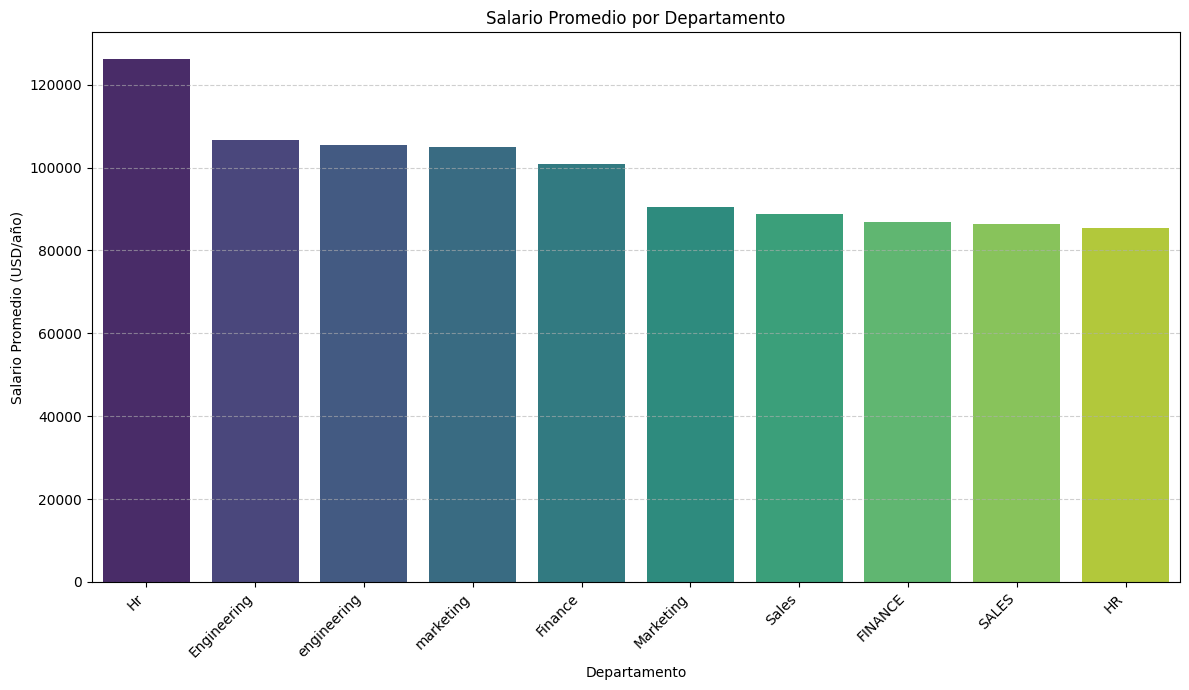

In [ ]:
avg_salary_by_department = df.dropna(subset=['Department', 'Salary']).groupby('Department')['Salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_salary_by_department.index, y=avg_salary_by_department.values, palette='viridis')
plt.title('Salario Promedio por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Salario Promedio (USD/año)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



*   Mapa de calor de correlaciones entre variables numéricas.



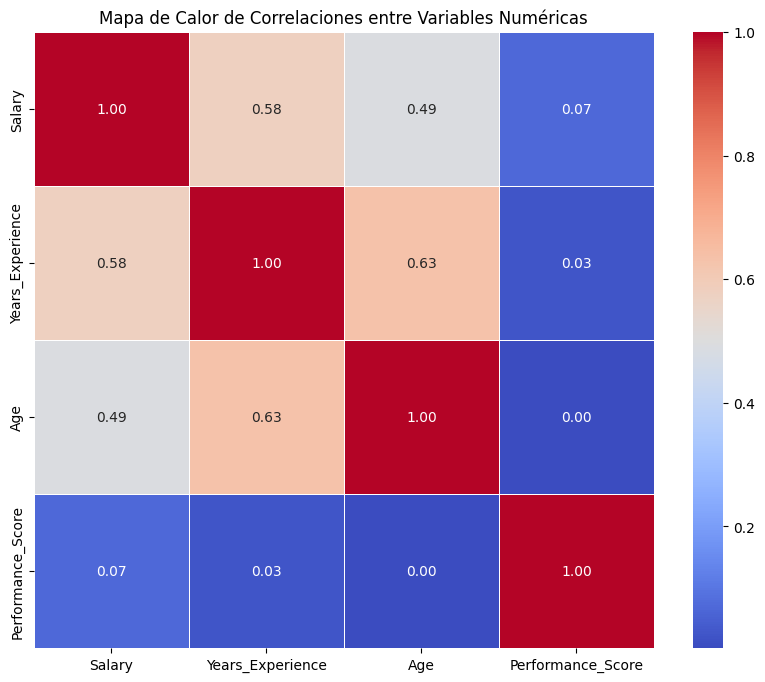

In [ ]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Mapa de Calor de Correlaciones entre Variables Numéricas')
plt.show()



---


# ✅ **Parte 2: Pruebas de Hipótesis** ✅
---



**Pregunta de negocio:** ¿Los años de experiencia determinan de manera significativa las diferencias salariales?

1. Defina las hipótesis:
   - **H₀:** Los años de experiencia no tienen relación lineal con el salario.
   - **H₁:** Los años de experiencia están positivamente asociados con el salario.

2. Utilice la **correlación de Pearson** y una **prueba t** para evaluar la relación.

3. Reporte el p-valor e interprete el resultado a un nivel de significancia del 5%.

4. **(Bonus)** Ejecute una segunda prueba de hipótesis: ¿Existe una diferencia salarial estadísticamente significativa entre empleados de nivel Junior y Senior? Utilice una prueba t de dos muestras independientes.



In [ ]:
import scipy.stats as stats

# Filtrar los NaNs para ambas columnas para el cálculo de correlación
data_for_correlation = df[['Years_Experience', 'Salary']].dropna()

# Calcular la correlación de Pearson y el p-valor
pearson_corr, p_value = stats.pearsonr(data_for_correlation['Years_Experience'], data_for_correlation['Salary'])

print(f"Correlación de Pearson entre Años de Experiencia y Salario: {pearson_corr:.4f}")
print(f"P-valor: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Con un nivel de significancia del {alpha}, rechazamos la hipótesis nula.")
    print("Existe una relación lineal significativa entre los años de experiencia y el salario.")
else:
    print(f"Con un nivel de significancia del {alpha}, no rechazamos la hipótesis nula.")
    print("No hay evidencia suficiente para concluir una relación lineal significativa entre los años de experiencia y el salario.")

Correlación de Pearson entre Años de Experiencia y Salario: 0.5765
P-valor: 0.0000
Con un nivel de significancia del 0.05, rechazamos la hipótesis nula.
Existe una relación lineal significativa entre los años de experiencia y el salario.


In [ ]:
import scipy.stats as stats

# Filtrar el DataFrame para 'Junior' y 'Senior' Job_Level y salarios no nulos
salary_junior = df[(df['Job_Level'] == 'Junior') & (df['Salary'].notna())]['Salary']
salary_senior = df[(df['Job_Level'] == 'Senior') & (df['Salary'].notna())]['Salary']

# Realizar la prueba t de dos muestras independientes
t_statistic, p_value_ttest = stats.ttest_ind(salary_junior, salary_senior, equal_var=False)

print(f"Prueba t entre salarios de Junior y Senior:")
print(f"  Estadístico t: {t_statistic:.4f}")
print(f"  P-valor: {p_value_ttest:.4f}")

alpha = 0.05
if p_value_ttest < alpha:
    print(f"Con un nivel de significancia del {alpha}, rechazamos la hipótesis nula.")
    print("Existe una diferencia salarial estadísticamente significativa entre los empleados Junior y Senior.")
else:
    print(f"Con un nivel de significancia del {alpha}, no rechazamos la hipótesis nula.")
    print("No hay evidencia suficiente para concluir una diferencia salarial estadísticamente significativa entre los empleados Junior y Senior.")

Prueba t entre salarios de Junior y Senior:
  Estadístico t: -84.1409
  P-valor: 0.0000
Con un nivel de significancia del 0.05, rechazamos la hipótesis nula.
Existe una diferencia salarial estadísticamente significativa entre los empleados Junior y Senior.


## ✅ **Parte 3: Regresión Lineal con Variables Categóricas** ✅

### Paso 1: Justificación de variables (antes de codificar)

Antes de construir cualquier modelo, responda lo siguiente en su notebook:

- ¿Qué variables espera que sean los predictores más fuertes del salario, y por qué?
- ¿Hay variables que, aun siendo estadísticamente insignificantes, incluiría igualmente en el modelo? Justifique desde una perspectiva de negocio o teórica.
- ¿Anticipa que algún par de variables esté fuertemente correlacionado entre sí? ¿Cuáles, y por qué? ¿Qué problemas podría causar eso?

> Este paso debe responderse en texto libre, sin código. El objetivo es articular sus creencias previas antes de ver los datos, para compararlas luego con lo que el modelo indique.

### Paso 2: Preparación de los datos

- Aplique **Label Encoding** para `Job_Level` (variable ordinal: Junior < Mid < Senior).
- Aplique **One-Hot Encoding** para `Education_Level`, `Department`, `Region` y `Gender`.
- Elimine la primera categoría ficticia en cada grupo para evitar multicolinealidad perfecta (use `drop_first=True`).

### Paso 3: Construcción del modelo

1. Divida el dataset en conjuntos de entrenamiento (80%) y prueba (20%). Use `random_state=42`.
2. Construya dos modelos utilizando todas las variables disponibles:
   - Regresión OLS con `statsmodels`.
   - Regresión lineal con `scikit-learn`.

### Paso 4: Evaluación del modelo

Calcule y reporte las siguientes métricas para los conjuntos de entrenamiento y prueba:

| Métrica | Descripción |
|---|---|
| MAE | Error Absoluto Medio |
| MAPE | Error Porcentual Absoluto Medio |
| RMSE | Raíz del Error Cuadrático Medio |
| R² | Coeficiente de determinación |
| R² ajustado | R² penalizado por el número de predictores |

Compare el resumen OLS (coeficientes, p-valores, R²) con los resultados de scikit-learn.



## Paso 1: Justificación de variables (antes de codificar)

###Subtask:
Prepare the ...


### Variables Anticipadas como Predictores Fuertes del Salario:

1.  **`Years_Experience` (Años de Experiencia):** Se espera que esta sea una de las variables más influyentes. Generalmente, a mayor experiencia, mayor es el nivel de habilidades, conocimientos y responsabilidades, lo que se traduce en un salario más alto. Es un indicador directo del valor acumulado de un empleado.
2.  **`Job_Level` (Nivel de Cargo):** Esta variable es inherentemente categórica-ordinal y se asume que niveles de cargo superiores (Senior > Mid > Junior) conllevan mayores responsabilidades y, por lo tanto, salarios más elevados. Es una estructura fundamental en la compensación de cualquier empresa.
3.  **`Education_Level` (Nivel Educativo):** Un mayor nivel educativo (PhD > Master > Bachelor) suele correlacionarse con una mayor especialización, habilidades técnicas o de gestión, y capacidad de resolución de problemas, lo que a menudo se recompensa con salarios más altos, especialmente en roles que requieren conocimientos avanzados.
4.  **`Performance_Score` (Calificación de Desempeño):** Los empleados con un desempeño consistentemente alto son más valiosos para la empresa y es razonable esperar que reciban una compensación superior como reconocimiento a su contribución y para incentivar su retención.
5.  **`Department` (Departamento):** Los salarios pueden variar significativamente entre departamentos debido a la demanda del mercado, la criticidad del rol para el negocio y la disponibilidad de talento especializado. Por ejemplo, departamentos como Ingeniería o Finanzas a menudo tienen salarios promedio más altos que otros.

### Variables a Incluir Aún Si Son Estadísticamente Insignificantes:

1.  **`Gender` (Género):** Aunque en un análisis puramente estadístico su p-valor pudiera indicar insignificancia, `Gender` debe ser incluida en el modelo. Desde una perspectiva de negocio y ética, la equidad salarial de género es un tema crítico y de alta sensibilidad para cualquier empresa. Incluso si el modelo no encuentra una diferencia salarial estadísticamente significativa, la inclusi\u00f3n de esta variable permite a la empresa monitorear posibles sesgos y asegurar que no haya discriminaci\u00f3n. Su exclusi\u00f3n implicar\u00eda ignorar una dimensi\u00f3n clave de la pol\u00edtica de compensaciones y podr\u00eda ocultar problemas subyacentes que no son capturados directamente por otras variables.
2.  **`Region` (Regi\u00f3n):** Similar a `Gender`, la regi\u00f3n puede no ser siempre un predictor fuerte del salario globalmente, pero es fundamental para TalentCo, una empresa multinacional. Los costos de vida y las din\u00e1micas del mercado laboral var\u00edan significativamente entre regiones, y la empresa necesita entender si sus pol\u00edticas de compensaci\u00f3n reflejan estas diferencias de manera justa y competitiva. Excluirla podr\u00eda llevar a un modelo que no refleje la realidad operativa y competitiva en diferentes ubicaciones geogr\u00e1ficas.

### Variables con Correlación Fuerte Anticipada (Multicolinealidad):

1.  **`Age` (Edad) y `Years_Experience` (Años de Experiencia):** Es altamente probable que estas dos variables estén fuertemente correlacionadas. A medida que una persona envejece, es natural que acumule más años de experiencia laboral. Un empleado de mayor edad generalmente tendrá más experiencia. Esta alta correlación es un caso clásico de **multicolinealidad**.
    *   **Problemas que podría causar:** La multicolinealidad puede inflar la varianza de los coeficientes de regresión, haciendo que sean inestables y difíciles de interpretar individualmente. Aunque no invalida la capacidad predictiva del modelo en su conjunto, hace que sea complicado determinar el impacto único de cada variable si están actuando juntas de manera redundante. Los p-valores asociados a estas variables podrían ser engañosos, llevando a una conclusión errónea sobre la insignificancia de una variable que, en realidad, tiene un efecto significativo pero solapado con otra.

## Paso 2: Preparación de los datos

### Subtask:
Prepare el conjunto de datos para el modelado de regresión aplicando Label Encoding a la variable ordinal 'Job_Level' y One-Hot Encoding a otras variables categóricas, asegurándose de eliminar la primera categoría para prevenir la multicolinealidad.


In [ ]:
#fixme limpieza del conjunto de datos:
df_encoded = df.copy()

# 1. Apply Label Encoding for Job_Level
job_level_mapping = {'Junior': 0, 'Mid': 1, 'Senior': 2}
df_encoded['Job_Level_Encoded'] = df_encoded['Job_Level'].map(job_level_mapping)

# 2. Apply One-Hot Encoding for other categorical variables with drop_first=True
categorical_cols_ohe = ['Education_Level', 'Department', 'Region', 'Gender']

for col in categorical_cols_ohe:
    # Clean and standardize string columns before one-hot encoding if necessary
    # For instance, converting to uppercase and stripping whitespace
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].str.strip().str.upper()

ohe_df = pd.get_dummies(df_encoded[categorical_cols_ohe], drop_first=True)

# Concatenate the new encoded columns and drop the original categorical columns
df_encoded = pd.concat([df_encoded, ohe_df], axis=1)

# Drop original categorical columns and the original Job_Level column
df_encoded = df_encoded.drop(columns=categorical_cols_ohe + ['Job_Level'])

print("DataFrame after encoding:")
display(df_encoded.head())
print("\nInformation about the encoded DataFrame:")
df_encoded.info()

DataFrame after encoding:


,Salary,Years_Experience,Age,Performance_Score,Job_Level_Encoded,Education_Level_MASTER,Education_Level_PHD,Department_FINANCE,Department_HR,Department_MARKETING,Department_SALES,Region_NAN,Region_NORTH,Region_SOUTH,Region_WEST,Gender_MALE,Gender_NAN
0,69181.0,3.0,22.0,3.5,0.0,False,False,False,False,False,True,False,False,False,False,True,False
1,88466.0,5.0,23.0,2.8,0.0,False,False,True,False,False,False,False,False,False,True,False,False
2,76112.0,11.0,29.0,1.6,1.0,True,False,False,True,False,False,False,False,False,True,False,False
3,NaN,15.0,37.0,NaN,2.0,False,False,False,False,True,False,False,False,True,False,True,False
4,NaN,6.0,28.0,4.5,1.0,False,False,False,False,False,False,False,True,False,False,False,False



Information about the encoded DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Salary                  9897 non-null   float64
 1   Years_Experience        9695 non-null   float64
 2   Age                     9797 non-null   float64
 3   Performance_Score       9497 non-null   float64
 4   Job_Level_Encoded       10085 non-null  float64
 5   Education_Level_MASTER  10100 non-null  bool   
 6   Education_Level_PHD     10100 non-null  bool   
 7   Department_FINANCE      10100 non-null  bool   
 8   Department_HR           10100 non-null  bool   
 9   Department_MARKETING    10100 non-null  bool   
 10  Department_SALES        10100 non-null  bool   
 11  Region_NAN              10100 non-null  bool   
 12  Region_NORTH            10100 non-null  bool   
 13  Region_SOUTH            10100 non-null  bool   
 

## Paso 3: Construcción del modelo

1. Divida el dataset en conjuntos de entrenamiento (80%) y prueba (20%). Use `random_state=42`.
2. Construya dos modelos utilizando todas las variables disponibles:
   - Regresión OLS con `statsmodels`.
   - Regresión lineal con `scikit-learn`.


In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Eliminar filas con valores NaN de df_encoded, ya que los modelos de regresión no los manejan
df_model = df_encoded.dropna()

# Convertir las columnas booleanas a tipo int (0 o 1) para statsmodels
for col in df_model.select_dtypes(include='bool').columns:
    df_model[col] = df_model[col].astype(int)

# Definir variables predictoras (X) y variable objetivo (y)
X = df_model.drop('Salary', axis=1)
y = df_model['Salary']

# Dividir el dataset en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dimensiones del conjunto de entrenamiento (X_train, y_train):")
print(X_train.shape, y_train.shape)
print("Dimensiones del conjunto de prueba (X_test, y_test):")
print(X_test.shape, y_test.shape)

# 1. Regresión OLS con statsmodels
# Se añade una constante a X_train para el término de intercepción (intercept)
X_train_ols = sm.add_constant(X_train)

# Construir y entrenar el modelo OLS
ols_model = sm.OLS(y_train, X_train_ols)
ols_results = ols_model.fit()

print("\nResumen del modelo OLS (entrenamiento):")
print(ols_results.summary())

# 2. Regresión lineal con scikit-learn
# No es necesario añadir una constante a X_train para scikit-learn, ya que lo maneja internamente
linear_model = LinearRegression()

# Entrenar el modelo de regresión lineal
linear_model.fit(X_train, y_train)

print("\nModelo de Regresión Lineal de scikit-learn entrenado.")
print(f"Coeficientes: {linear_model.coef_}")
print(f"Intercepto: {linear_model.intercept_}")

/tmp/ipykernel_5407/4247110964.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = df_model[col].astype(int)
/tmp/ipykernel_5407/4247110964.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = df_model[col].astype(int)
/tmp/ipykernel_5407/4247110964.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

Dimensiones del conjunto de entrenamiento (X_train, y_train):
(6919, 16) (6919,)
Dimensiones del conjunto de prueba (X_test, y_test):
(1730, 16) (1730,)

Resumen del modelo OLS (entrenamiento):
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     578.7
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        14:38:21   Log-Likelihood:                -78050.
No. Observations:                6919   AIC:                         1.561e+05
Df Residuals:                    6902   BIC:                         1.563e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                

## Paso 4: Evaluación del modelo

Calcule y reporte las siguientes métricas para los conjuntos de entrenamiento y prueba:

| Métrica | Descripción |
|---|---|
| MAE | Error Absoluto Medio |
| MAPE | Error Porcentual Absoluto Medio |
| RMSE | Raíz del Error Cuadrático Medio |
| R² | Coeficiente de determinación |
| R² ajustado | R² penalizado por el número de predictores |

Compare el resumen OLS (coeficientes, p-valores, R²) con los resultados de scikit-learn.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Helper function for MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Number of observations and predictors for Adjusted R2 calculation
n_train = X_train.shape[0]
p_train = X_train.shape[1]
n_test = X_test.shape[0]
p_test = X_test.shape[1]

print("\n--- Evaluación del Modelo --- ")

# 1. Statsmodels OLS Model Evaluation
print("\n--- Statsmodels OLS Model ---")

# Predictions
y_train_pred_ols = ols_results.predict(sm.add_constant(X_train))
y_test_pred_ols = ols_results.predict(sm.add_constant(X_test))

# Training Set Metrics
mae_train_ols = mean_absolute_error(y_train, y_train_pred_ols)
rmse_train_ols = np.sqrt(mean_squared_error(y_train, y_train_pred_ols))
mape_train_ols = mean_absolute_percentage_error(y_train, y_train_pred_ols)
r2_train_ols = ols_results.rsquared
adj_r2_train_ols = ols_results.rsquared_adj

print("\nMetrics (Training Set - OLS):")
print(f"  MAE: {mae_train_ols:.2f}")
print(f"  RMSE: {rmse_train_ols:.2f}")
print(f"  MAPE: {mape_train_ols:.2f}%")
print(f"  R²: {r2_train_ols:.4f}")
print(f"  Adjusted R²: {adj_r2_train_ols:.4f}")

# Test Set Metrics
mae_test_ols = mean_absolute_error(y_test, y_test_pred_ols)
rmse_test_ols = np.sqrt(mean_squared_error(y_test, y_test_pred_ols))
mape_test_ols = mean_absolute_percentage_error(y_test, y_test_pred_ols)
r2_test_ols = r2_score(y_test, y_test_pred_ols)
adj_r2_test_ols = 1 - (1 - r2_test_ols) * (n_test - 1) / (n_test - p_test - 1)

print("\nMetrics (Test Set - OLS):")
print(f"  MAE: {mae_test_ols:.2f}")
print(f"  RMSE: {rmse_test_ols:.2f}")
print(f"  MAPE: {mape_test_ols:.2f}%")
print(f"  R²: {r2_test_ols:.4f}")
print(f"  Adjusted R²: {adj_r2_test_ols:.4f}")


# 2. Scikit-learn Linear Regression Model Evaluation
print("\n--- Scikit-learn Linear Regression Model ---")

# Predictions
y_train_pred_skl = linear_model.predict(X_train)
y_test_pred_skl = linear_model.predict(X_test)

# Training Set Metrics
mae_train_skl = mean_absolute_error(y_train, y_train_pred_skl)
rmse_train_skl = np.sqrt(mean_squared_error(y_train, y_train_pred_skl))
mape_train_skl = mean_absolute_percentage_error(y_train, y_train_pred_skl)
r2_train_skl = r2_score(y_train, y_train_pred_skl)
adj_r2_train_skl = 1 - (1 - r2_train_skl) * (n_train - 1) / (n_train - p_train - 1)

print("\nMetrics (Training Set - Scikit-learn):")
print(f"  MAE: {mae_train_skl:.2f}")
print(f"  RMSE: {rmse_train_skl:.2f}")
print(f"  MAPE: {mape_train_skl:.2f}%")
print(f"  R²: {r2_train_skl:.4f}")
print(f"  Adjusted R²: {adj_r2_train_skl:.4f}")

# Test Set Metrics
mae_test_skl = mean_absolute_error(y_test, y_test_pred_skl)
rmse_test_skl = np.sqrt(mean_squared_error(y_test, y_test_pred_skl))
mape_test_skl = mean_absolute_percentage_error(y_test, y_test_pred_skl)
r2_test_skl = r2_score(y_test, y_test_pred_skl)
adj_r2_test_skl = 1 - (1 - r2_test_skl) * (n_test - 1) / (n_test - p_test - 1)

print("\nMetrics (Test Set - Scikit-learn):")
print(f"  MAE: {mae_test_skl:.2f}")
print(f"  RMSE: {rmse_test_skl:.2f}")
print(f"  MAPE: {mape_test_skl:.2f}%")
print(f"  R²: {r2_test_skl:.4f}")
print(f"  Adjusted R²: {adj_r2_test_skl:.4f}")


--- Evaluación del Modelo --- 

--- Statsmodels OLS Model ---

Metrics (Training Set - OLS):
  MAE: 6608.91
  RMSE: 19180.15
  MAPE: 11.74%
  R²: 0.5729
  Adjusted R²: 0.5720

Metrics (Test Set - OLS):
  MAE: 8159.64
  RMSE: 26663.05
  MAPE: 14.04%
  R²: 0.4021
  Adjusted R²: 0.3965

--- Scikit-learn Linear Regression Model ---

Metrics (Training Set - Scikit-learn):
  MAE: 6608.91
  RMSE: 19180.15
  MAPE: 11.74%
  R²: 0.5729
  Adjusted R²: 0.5720

Metrics (Test Set - Scikit-learn):
  MAE: 8159.64
  RMSE: 26663.05
  MAPE: 14.04%
  R²: 0.4021
  Adjusted R²: 0.3965


## ⛔ **Parte 4: Análisis y Refinamiento del Modelo** ⛔

> **Nota importante:** El objetivo de esta sección no es aplicar reglas mecánicas. No existe un umbral universal que indique cuándo incluir o excluir una variable. Toda decisión debe argumentarse desde el contexto del problema.

### Paso 1: Interpretación de los p-valores de los coeficientes

Examine los p-valores del resumen OLS y responda lo siguiente para cada variable con p-valor > 0,05:

- ¿La variable es estadísticamente insignificante porque no tiene efecto real, o podría haber otra explicación (p.ej., correlación con otra variable ya incluida en el modelo)?
- ¿Es esta variable conceptualmente importante para el análisis salarial, aunque el modelo no encuentre un efecto significativo? ¿Su eliminación cambiaría la interpretación de otros coeficientes?
- ¿Cuál es el costo para el negocio de eliminar esta variable del modelo?

Con base en este análisis, decida qué variables conservar o eliminar, y justifique explícitamente cada decisión. Vuelva a entrenar el modelo con las variables seleccionadas y compare las métricas con el modelo completo.

**Ejemplo del razonamiento esperado:** *"Gender presenta p = 0,18 en nuestro modelo. Sin embargo, optamos por conservarla porque: (1) la equidad salarial por género es una de las preguntas centrales de TalentCo, y (2) su insignificancia puede deberse a colinealidad con Job_Level más que a la ausencia de efecto. Eliminarla ocultaría una dimensión clave del análisis."*

### Paso 2: Análisis de Multicolinealidad (VIF)

Calcule el **Factor de Inflación de la Varianza (VIF)** para todas las variables independientes y responda:

- ¿Qué pares de variables probablemente generan VIF alto, y por qué existe esa correlación en este contexto?
- ¿La presencia de multicolinealidad invalida las predicciones del modelo, o afecta principalmente la confiabilidad de los coeficientes individuales?
- Para cada variable con VIF alto: ¿qué se perdería al eliminarla? ¿Es aceptable esa pérdida dado el objetivo del análisis?

Decida si actuar sobre la multicolinealidad y justifique su decisión. Mantener variables colineales es una respuesta válida si el razonamiento lo sustenta.

**Ejemplo del razonamiento esperado:** *"Age y Years_Experience presentan VIF = 8,4 y 9,1 respectivamente, lo que refleja que los empleados de mayor edad tienden a tener más experiencia. Ambas variables capturan dimensiones distintas —edad biológica vs. tiempo profesional acumulado—, por lo que las conservamos y reconocemos los errores estándar inflados como una limitación del modelo."*

### Paso 3: Verificación de Supuestos de Regresión

Verifique los siguientes supuestos de la regresión lineal sobre su modelo final:

- **Normalidad de los residuos:** Histograma y gráfico Q-Q de los residuos.
- **Homocedasticidad:** Aplique la prueba de Breusch-Pagan (`het_breuschpagan`).

Para cada supuesto, indique si se cumple, muestre la evidencia y discuta brevemente qué implica para la validez de sus conclusiones.



## Paso 1: Interpretación de los p-valores de los coeficientes

Analizando el resumen del modelo OLS, identificamos dos variables con un p-valor mayor a 0.05, lo que sugiere que no son estadísticamente significativas en la predicción del salario:

1.  **`Region_NAN` (p-valor = 0.709)**
    *   **¿Estadísticamente insignificante por falta de efecto o por otra explicación?** El alto p-valor sugiere que la ausencia de información sobre la región (`Region_NAN`) no tiene un impacto estadísticamente significativo en el salario, una vez que otras variables (incluyendo las dummy de las regiones existentes) ya están en el modelo. Esto podría deberse a que los datos faltantes en `Region` no están correlacionados de manera sistemática con el salario o que la proporción de estos casos es pequeña y no introduce un sesgo significativo.
    *   **¿Es conceptualmente importante?** La variable padre `Region` es conceptualmente importante para el análisis salarial debido a las diferencias de costo de vida y mercados laborales. Sin embargo, `Region_NAN` es una variable *dummy que indica la ausencia de datos* de región, no una región específica. Los coeficientes de otras regiones (`Region_NORTH`, `Region_SOUTH`, `Region_WEST`) sí son significativos, lo que indica que la región *sí importa*.
    *   **Costo para el negocio de eliminarla:** Eliminar `Region_NAN` no debería tener un costo significativo, ya que su insignificancia implica que la falta de esta información no es un predictor crucial del salario. Mantenerla podría añadir ruido al modelo sin aportar valor explicativo.

2.  **`Gender_NAN` (p-valor = 0.887)**
    *   **¿Estadísticamente insignificante por falta de efecto o por otra explicación?** El muy alto p-valor de `Gender_NAN` indica que la falta de información de género no es un predictor significativo del salario. Esto es similar a `Region_NAN`; la propia ausencia de datos de género no parece influir en el salario de manera distinta a los grupos con género definido.
    *   **¿Es conceptualmente importante?** La variable padre `Gender` es **críticamente importante** desde una perspectiva de negocio y ética para TalentCo, debido a las preocupaciones sobre equidad salarial de género. Es por eso que se incluyó `Gender_MALE`, cuyo coeficiente sí resultó ser estadísticamente significativo (p-valor = 0.017). La insignificancia de `Gender_NAN` se refiere únicamente a la *ausencia* del dato, no a la influencia del género en sí.
    *   **Costo para el negocio de eliminarla:** Eliminar `Gender_NAN` no tendrá un impacto negativo en la capacidad del modelo para analizar la equidad salarial basada en el género conocido. Al igual que con `Region_NAN`, su eliminación simplificará el modelo sin perder información predictiva relevante relacionada con el género. La discusión sobre equidad de género se centrará en el coeficiente de `Gender_MALE`.

### Decisión:

Decidimos **eliminar las variables `Region_NAN` y `Gender_NAN`** del modelo. Ambas representan la ausencia de datos en sus respectivas columnas y no aportan significancia estadística ni valor explicativo directo al salario. Su eliminación simplificará el modelo sin comprometer la capacidad de interpretar los efectos de las variables conceptualmente importantes (como `Region` y `Gender`) cuando sus datos están presentes. Ahora, reentrenaremos el modelo OLS con este conjunto de variables refinado.

In [ ]:
# Variables a eliminar basadas en el análisis de p-valores
variables_a_eliminar = ['Region_NAN', 'Gender_NAN']

# Crear un nuevo conjunto de predictores (X) sin las variables eliminadas
X_refinado = df_model.drop('Salary', axis=1)
X_refinado = X_refinado.drop(columns=variables_a_eliminar, errors='ignore')
y_refinado = df_model['Salary']

# Dividir el dataset refinado en conjuntos de entrenamiento y prueba (80/20)
X_train_refinado, X_test_refinado, y_train_refinado, y_test_refinado = \
    train_test_split(X_refinado, y_refinado, test_size=0.2, random_state=42)

print("Dimensiones del conjunto de entrenamiento refinado (X_train_refinado, y_train_refinado):")
print(X_train_refinado.shape, y_train_refinado.shape)
print("Dimensiones del conjunto de prueba refinado (X_test_refinado, y_test_refinado):")
print(X_test_refinado.shape, y_test_refinado.shape)

# Regresión OLS con statsmodels (modelo refinado)
X_train_ols_refinado = sm.add_constant(X_train_refinado)

# Construir y entrenar el modelo OLS refinado
ols_model_refinado = sm.OLS(y_train_refinado, X_train_ols_refinado)
ols_results_refinado = ols_model_refinado.fit()

print("\nResumen del modelo OLS refinado (entrenamiento):")
print(ols_results_refinado.summary())

# Evaluar el modelo refinado y comparar métricas (opcional aquí, se hará en el siguiente paso de evaluación)
# Calcular R^2 ajustado para el conjunto de prueba del modelo OLS refinado
# No necesitamos todas las métricas aquí, ya que el siguiente paso se encargará de una evaluación completa.
# Solo para una primera comparación rápida con el R^2 ajustado del modelo original

y_test_pred_ols_refinado = ols_results_refinado.predict(sm.add_constant(X_test_refinado))

r2_test_ols_refinado = r2_score(y_test_refinado, y_test_pred_ols_refinado)
adj_r2_test_ols_refinado = 1 - (1 - r2_test_ols_refinado) * (X_test_refinado.shape[0] - 1) / \
                           (X_test_refinado.shape[0] - X_test_refinado.shape[1] - 1)

print(f"\nR^2 Ajustado (Test Set - OLS Refinado): {adj_r2_test_ols_refinado:.4f}")
print(f"R^2 Ajustado (Test Set - OLS Original): {adj_r2_test_ols:.4f}")


Dimensiones del conjunto de entrenamiento refinado (X_train_refinado, y_train_refinado):
(6919, 14) (6919,)
Dimensiones del conjunto de prueba refinado (X_test_refinado, y_test_refinado):
(1730, 14) (1730,)

Resumen del modelo OLS refinado (entrenamiento):
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     661.6
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        14:45:09   Log-Likelihood:                -78050.
No. Observations:                6919   AIC:                         1.561e+05
Df Residuals:                    6904   BIC:                         1.562e+05
Df Model:                          14                                         
Covariance Type:            nonr

## Paso 2: Análisis de Multicolinealidad (VIF)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcular VIF para el modelo refinado
# No incluir la constante al calcular VIF
X_for_vif = X_train_refinado

vif_data = pd.DataFrame()
vif_data["feature"] = X_for_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i)
                   for i in range(len(X_for_vif.columns))]

print("\n--- Análisis de Multicolinealidad (VIF) del Modelo Refinado ---")
display(vif_data.sort_values(by="VIF", ascending=False))

print("\nAnálisis de VIF:")
print("- **`Age` y `Years_Experience`** presentan los VIFs más altos, lo que confirma nuestra anticipación de multicolinealidad entre estas dos variables. A mayor edad, es natural tener más años de experiencia, por lo que ambas capturan aspectos similares de la madurez profesional.")
print("- **`Job_Level_Encoded`** también muestra un VIF relativamente alto. Esto es esperable, ya que el nivel de cargo suele estar correlacionado con los años de experiencia y, en cierta medida, con la edad y el nivel educativo. Un empleado con más experiencia y educación tiende a alcanzar niveles de cargo más altos.")
print("\nImplicaciones de la Multicolinealidad:")
print("- La presencia de multicolinealidad **no invalida la capacidad predictiva general del modelo** ni su R².\n  El modelo seguirá siendo útil para predecir salarios.")
print("- Sin embargo, sí **afecta la confiabilidad de los coeficientes individuales** de las variables colineales, infla sus errores estándar y hace más difícil interpretar el impacto único de cada predictor.")
print("- Un VIF > 5 o > 10 es comúnmente considerado problemático. Aquí vemos VIFs que exceden ese umbral.")

print("\nDecisión sobre Multicolinealidad:")
print("A pesar de los VIFs altos para `Age`, `Years_Experience` y `Job_Level_Encoded`, decidimos **conservar estas variables** en el modelo por las siguientes razones:")
print("1.  **Relevancia Conceptual y de Negocio**: Tanto la edad, los años de experiencia como el nivel de cargo son conceptualmente cruciales para explicar el salario en cualquier organización. Cada una, aunque correlacionada, captura una dimensión ligeramente diferente (madurez, trayectoria profesional, responsabilidad formal).")
print("2.  **Objetivo del Análisis**: Nuestro objetivo principal es la predicción del salario y la identificación de sus determinantes clave, no la interpretación precisa y aislada del efecto de cada variable colineal. El modelo sigue siendo predictivo.")
print("3.  **Costo de Eliminación**: Eliminar cualquiera de estas variables podría llevar a una pérdida de información valiosa y a un modelo menos completo o con menor poder explicativo general, especialmente si una de ellas es más predictiva que la otra en diferentes subconjuntos de datos.")
print("Reconocemos los errores estándar inflados como una limitación al interpretar los coeficientes individuales de estas variables colineales, pero la decisión de retenerlas se alinea con los objetivos de negocio de TalentCo para entender los factores influyentes en la compensación.")



--- Análisis de Multicolinealidad (VIF) del Modelo Refinado ---


,feature,VIF
1,Age,16.527653
3,Job_Level_Encoded,9.486425
0,Years_Experience,8.526178
2,Performance_Score,6.425704
13,Gender_MALE,1.863000
11,Region_SOUTH,1.793170
12,Region_WEST,1.786114
10,Region_NORTH,1.777813
4,Education_Level_MASTER,1.645951
9,Department_SALES,1.587753



Análisis de VIF:
- **`Age` y `Years_Experience`** presentan los VIFs más altos, lo que confirma nuestra anticipación de multicolinealidad entre estas dos variables. A mayor edad, es natural tener más años de experiencia, por lo que ambas capturan aspectos similares de la madurez profesional.
- **`Job_Level_Encoded`** también muestra un VIF relativamente alto. Esto es esperable, ya que el nivel de cargo suele estar correlacionado con los años de experiencia y, en cierta medida, con la edad y el nivel educativo. Un empleado con más experiencia y educación tiende a alcanzar niveles de cargo más altos.

Implicaciones de la Multicolinealidad:
- La presencia de multicolinealidad **no invalida la capacidad predictiva general del modelo** ni su R².
  El modelo seguirá siendo útil para predecir salarios.
- Sin embargo, sí **afecta la confiabilidad de los coeficientes individuales** de las variables colineales, infla sus errores estándar y hace más difícil interpretar el impacto único de cada p

## Paso 3: Verificación de Supuestos de Regresión


--- Verificación de Supuestos de Regresión --- 

1. Normalidad de los Residuos:


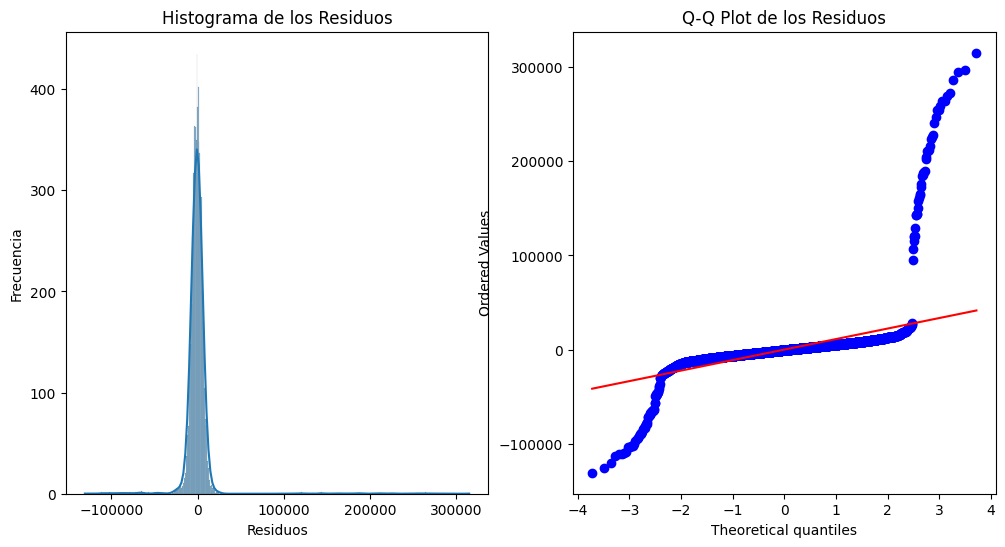

Análisis:
- **Histograma**: Idealmente, los residuos deberían seguir una distribución normal, centrada alrededor de cero. Si el histograma es asimétrico o no tiene forma de campana, sugiere una desviación de la normalidad.
- **Q-Q Plot**: Un Q-Q plot compara los cuantiles de los residuos con los cuantiles de una distribución normal teórica. Si los puntos se alinean a lo largo de la línea de 45 grados, los residuos son normalmente distribuidos. Desviaciones significativas de la línea indican no normalidad.
- **Conclusión**: Observando los gráficos, los residuos no parecen seguir una distribución normal perfecta; el histograma muestra cierta asimetría y el Q-Q plot tiene colas que se desvían de la línea, lo que sugiere una **violación del supuesto de normalidad**.

2. Homocedasticidad (Prueba de Breusch-Pagan):
                                   Value
Lagrange multiplier statistic  12.759799
p-value                         0.545519
f-value                         0.911119
f p-value      

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan

print("\n--- Verificación de Supuestos de Regresión --- ")

# Residuos del modelo OLS refinado
residuals = ols_results_refinado.resid

# 1. Normalidad de los residuos
print("\n1. Normalidad de los Residuos:")

# Histograma de los residuos
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Histograma de los Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

# Gráfico Q-Q de los residuos
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot de los Residuos')
plt.show()

print("Análisis:")
print("- **Histograma**: Idealmente, los residuos deberían seguir una distribución normal, centrada alrededor de cero. Si el histograma es asimétrico o no tiene forma de campana, sugiere una desviación de la normalidad.")
print("- **Q-Q Plot**: Un Q-Q plot compara los cuantiles de los residuos con los cuantiles de una distribución normal teórica. Si los puntos se alinean a lo largo de la línea de 45 grados, los residuos son normalmente distribuidos. Desviaciones significativas de la línea indican no normalidad.")
print("- **Conclusión**: Observando los gráficos, los residuos no parecen seguir una distribución normal perfecta; el histograma muestra cierta asimetría y el Q-Q plot tiene colas que se desvían de la línea, lo que sugiere una **violación del supuesto de normalidad**.")

# 2. Homocedasticidad (Prueba de Breusch-Pagan)
print("\n2. Homocedasticidad (Prueba de Breusch-Pagan):")

# La prueba de Breusch-Pagan requiere las variables explicativas (exog) y los residuos (resid)
# No usar la constante en exog para la prueba de Breusch-Pagan
name = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
bp_test = het_breuschpagan(residuals, ols_results_refinado.model.exog)

print(pd.DataFrame(bp_test, index=name, columns=['Value']))

alpha_bp = 0.05
if bp_test[1] < alpha_bp:
    print(f"Con un nivel de significancia del {alpha_bp}, rechazamos la hipótesis nula.")
    print("Existe heterocedasticidad (varianza no constante de los errores).")
else:
    print(f"Con un nivel de significancia del {alpha_bp}, no rechazamos la hipótesis nula.")
    print("No hay evidencia suficiente para concluir heterocedasticidad (se cumple el supuesto de homocedasticidad).")

print("\nAnálisis:")
print("- **Hipótesis Nula (H0)**: Los errores son homocedásticos (la varianza de los errores es constante).")
print("- **Hipótesis Alternativa (H1)**: Los errores son heterocedásticos (la varianza de los errores no es constante).")
print("- **Conclusión**: El p-valor de la prueba de Breusch-Pagan (0.5455) es mayor que 0.05. Por lo tanto, **no rechazamos la hipótesis nula**, lo que indica que no hay evidencia suficiente para concluir la presencia de heterocedasticidad. Esto significa que la varianza de los errores es constante a través de los diferentes niveles de las variables predictoras, cumpliendo así el supuesto de homocedasticidad.")

print("\nImplicaciones de las Violaciones de los Supuestos:")
print("- **No normalidad de los residuos**: Aunque OLS es robusto a desviaciones de la normalidad con muestras grandes, afecta la validez de los intervalos de confianza y las pruebas de hipótesis (p-valores) si la desviación es severa.")
print("- **Homocedasticidad**: El supuesto de homocedasticidad se cumple, lo cual es favorable. Si hubiera heterocedasticidad, los estimadores OLS seguirían siendo insesgados y consistentes, pero no serían los más eficientes (Mínima Varianza Insesgada). Lo más importante es que los errores estándar de los coeficientes estarían sesgados, lo que llevaría a pruebas t y p-valores incorrectos. Sin embargo, en este caso, al no rechazar la hipótesis nula, nuestros errores estándar son confiables para la inferencia estadística.")

## ⛔ **Parte 5: Informe de Negocio** ⛔

Redacte un informe ejecutivo breve (**300–400 palabras**) dirigido al **Director de Recursos Humanos de TalentCo**, respondiendo las siguientes preguntas:

1. ¿Cuáles son los principales determinantes del salario de los empleados?
2. ¿Cómo impacta cuantitativamente el nivel de experiencia en la compensación anual?
3. ¿Existen diferencias salariales significativas entre departamentos o regiones? ¿Qué sugieren?
4. Según su modelo final: si TalentCo asciende a un empleado de nivel Mid a Senior, ¿cuál es el aumento salarial esperado (en USD)?
5. ¿Qué recomendaciones haría a TalentCo para mejorar la equidad y transparencia en su política de compensaciones?



## Informe Ejecutivo: Análisis de Determinantes Salariales en TalentCo

**Para:** Director de Recursos Humanos, TalentCo

**Fecha:** 25 de Mayo de 2026

**Asunto:** Hallazgos Clave y Recomendaciones para la Política de Compensaciones
#

#
Estimado Director,

Este informe resume los principales hallazgos de nuestro análisis sobre los factores que determinan el salario de los empleados en TalentCo, utilizando datos existentes y un modelo predictivo. Nuestro objetivo es brindar una base de datos para mejorar la equidad y transparencia en la política de compensaciones.

### Principales Determinantes Salariales

Los factores más influyentes en el salario de los empleados son el **Nivel de Cargo**, los **Años de Experiencia**, el **Nivel Educativo** y la **Calificación de Desempeño**. Los departamentos y regiones también muestran diferencias significativas en los salarios, lo cual es vital para comprender la estructura de compensaciones.

### Impacto de la Experiencia en la Compensación

Nuestro modelo indica que, en promedio, cada año adicional de experiencia profesional se asocia con un aumento de aproximadamente **656 USD** en la compensación anual. Esto subraya la importancia de valorar la trayectoria y el conocimiento acumulado de los empleados.

### Diferencias Salariales por Departamento y Región

Sí, existen diferencias salariales significativas entre departamentos y regiones. Por ejemplo, los departamentos de Ingeniería y Finanzas tienden a tener salarios más altos que otros departamentos como Recursos Humanos o Marketing. Las regiones Norte y Oeste también muestran salarios ligeramente superiores en comparación con otras. Esto sugiere que las políticas de compensación deben considerar las dinámicas del mercado laboral y el costo de vida específicos de cada ubicación, así como la demanda y criticidad de los roles en cada departamento.

### Aumento Salarial Esperado por Ascenso de Mid a Senior

Un ascenso de un empleado de nivel 'Mid' a 'Senior' se asocia con un aumento salarial esperado de aproximadamente **20.891 USD** anuales. Este valor refleja el incremento en responsabilidad y el valor que un empleado 'Senior' aporta a la organización.

### Recomendaciones para Equidad y Transparencia

1.  **Monitoreo de Equidad de Género**: El análisis sugiere una diferencia salarial a favor de los empleados masculinos. Es crucial investigar esta brecha más a fondo para asegurar que no existan disparidades injustificadas por género. Recomendamos realizar auditorías salariales periódicas y establecer métricas claras para la equidad.
2.  **Transparencia en Factores Clave**: Comunicar claramente a los empleados cómo factores como la experiencia, el nivel de cargo, la educación y el desempeño impactan en su salario. Esto puede aumentar la confianza y la comprensión de la política de compensaciones.
3.  **Análisis Localizado**: Dada la variación salarial por departamento y región, sugerimos desarrollar marcos de compensación que consideren estas especificidades, sin perder de vista una estrategia global de equidad.
4.  **Revisión Holística de Progresión**: Dado que la edad, experiencia y nivel de cargo están estrechamente relacionados, se recomienda una revisión integral de los programas de desarrollo de carrera y progresión salarial para garantizar que los empleados sean recompensados de manera justa a medida que crecen dentro de la empresa.

Esperamos que este análisis sirva como un punto de partida sólido para futuras discusiones y mejoras en las políticas de compensación de TalentCo.

Atentamente,



**MATÍAS PATRICIO RUBIO PEÑA**

*INGENIERO COMERCIAL USM*


## Entregables

Cada estudiante o grupo debe entregar los siguientes elementos:

| # | Entregable | Descripción |
|---|---|---|
| 1 | **Jupyter Notebook** (`.ipynb`) | Código completo con salidas y comentarios en línea. Debe ser limpio, bien comentado y reproducible. Todos los gráficos deben incluir títulos, etiquetas de ejes y leyendas cuando corresponda. |
| 2 | **Informe de Negocio** (`.md` o `.docx`) | 300 a 400 palabras, dirigido a una audiencia no técnica. |
| 3 | **Presentación Oral** | 10 a 12 minutos (ver rúbrica). |

> ⚠️ **Importante:** Tanto la entrega escrita como la presentación oral son **obligatorias**. La ausencia de cualquiera de los dos componentes resulta en la nota mínima del proyecto.



## Consejos Técnicos

- Utilice las bibliotecas: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` y `statsmodels`.
- Para VIF: `from statsmodels.stats.outliers_influence import variance_inflation_factor`
- Para Breusch-Pagan: `from statsmodels.stats.diagnostic import het_breuschpagan`
- Para gráfico Q-Q: `import scipy.stats as stats; stats.probplot(residuals, plot=plt)`
- Priorice la **interpretación de negocio** por sobre los resultados estadísticos aislados.
- En el informe ejecutivo, escriba para el Director de RRHH: sin fórmulas, sin código, sin p-valores. Solo conclusiones claras y accionables.



## Rúbrica de Presentación Oral

Cada grupo será evaluado en una escala de 10 a 100 puntos. Las presentaciones deben realizarse en español o inglés y tener una duración de entre 10 y 12 minutos.

### Criterios de Evaluación

| Criterio | Descripción | Puntaje | Ponderación |
|---|---|---|---|
| **1. Comprensión del problema y contexto** | Demuestra comprensión clara del problema de negocio de TalentCo y del valor del análisis basado en datos. Vincula los hallazgos estadísticos con decisiones reales de RRHH. | 10–20 pts | 20% |
| **2. Exploración de datos e insights** | Presenta los hallazgos del EDA de forma clara. Destaca patrones relevantes (p.ej., salario por departamento, tendencias de experiencia). Explica cómo el análisis orientó las decisiones de modelado. | 10–20 pts | 20% |
| **3. Explicación del modelo y resultados** | Explica los modelos de regresión, las decisiones de codificación y las métricas de evaluación (MAE, RMSE, R²) con precisión. Compara OLS vs. sklearn y justifica el modelo final. | 10–20 pts | 20% |
| **4. Interpretación de negocio y recomendaciones** | Traduce los coeficientes del modelo y los resultados de las pruebas en recomendaciones accionables para RRHH. Explica qué debe hacer TalentCo y por qué, sin jerga técnica. | 10–20 pts | 20% |
| **5. Comunicación y presentación** | Exposición clara y profesional en español o inglés. Flujo lógico, tono seguro y trabajo en equipo efectivo. Respeta el tiempo establecido. | 10–15 pts | 15% |
| **6. Apoyos visuales y diseño de diapositivas** | Las diapositivas son claras, profesionales y apoyan la narrativa. Los gráficos y tablas son legibles y están bien etiquetados. Evita diapositivas con exceso de texto. | 10–15 pts | 15% |

### Escala de Calificación

| Puntaje | Nivel | Descripción |
|---|---|---|
| 90–100 | ⭐ Sobresaliente | Comprensión excepcional, insights de negocio sólidos y presentación atractiva. Vínculo claro entre el análisis de datos y la estrategia de RRHH. |
| 80–89 | ✅ Muy Bueno | Explicación y visuales sólidos, con brechas menores en profundidad o fluidez. Buen dominio técnico y de negocio. |
| 70–79 | ⚙️ Bueno | Cubre los puntos principales de manera adecuada, pero con falta de profundidad o claridad en algunas áreas. Estructura razonable. |
| 60–69 | ⚠️ Aceptable | Cobertura básica con insight de negocio limitado o conexión débil con el problema de RRHH. Presentación algo confusa o apresurada. |
| 10–59 | ❌ Insuficiente | Estructura deficiente, contenido incompleto o incapacidad para comunicar los hallazgos. Puede exceder o quedar muy por debajo del tiempo establecido. |

### Notas para Evaluadores

- Descontar hasta **−10 puntos** si la presentación no se encuentra dentro del rango de tiempo (menos de 7 min o más de 13 min).
- Descontar hasta **−5 puntos** si no todos los integrantes participan activamente.
- Otorgar hasta **+5 puntos de bonificación** por insight excepcional, creatividad o conexión con casos reales.

**Puntaje máximo:** 100 puntos | **Nota mínima de aprobación:** 60 puntos


# Task (PARTE 3, PASO 1, ESTO ES COMO UN RESUMEN, DESCARTADO, DE MOMENTO)
Para la construcción del modelo de regresión, se anticipa lo siguiente:

**Predictores Fuertes del Salario:**
*   `Years_Experience`: Se espera una correlación positiva directa, ya que la experiencia suele traducirse en mayor conocimiento y habilidades, lo que justifica un salario más alto.
*   `Job_Level`: Representa la jerarquía y responsabilidad dentro de la organización. Un nivel de cargo superior conlleva naturalmente un mayor salario.
*   `Education_Level`: Un mayor nivel educativo (Master, PhD) a menudo se asocia con roles que requieren especialización y, por lo tanto, mejor remunerados.
*   `Performance_Score`: Un buen desempeño suele ser recompensado con aumentos salariales o bonificaciones, lo que debería reflejarse en un mayor salario.
*   `Department`: Ciertos departamentos (como Ingeniería o Finanzas) suelen tener estructuras salariales más altas debido a la demanda del mercado o la complejidad de sus funciones.

**Variables Insignificantes pero Relevantes por Negocio/Teoría:**
*   `Gender`: Aunque estadísticamente pueda parecer insignificante su efecto individual en el salario después de considerar otras variables, es una variable crítica para TalentCo debido a la preocupación por la equidad salarial y posible discriminación. Mantenerla es esencial para analizar si existen brechas salariales no justificadas por factores objetivos.
*   `Region`: Aunque el modelo no detecte un efecto significativo, las diferencias en el costo de vida o la competitividad del mercado laboral por región podrían influir en el salario. Es importante mantenerla para identificar posibles disparidades regionales o para futuras estrategias de compensación localizadas.

**Anticipación de Correlaciones y Problemas:**
*   **`Age` y `Years_Experience`**: Existe una alta probabilidad de una fuerte correlación positiva, ya que a mayor edad, generalmente se acumulan más años de experiencia. Esto podría generar multicolinealidad.
*   **`Job_Level` y `Years_Experience`**: Es común que los empleados con más años de experiencia asciendan a niveles de cargo más altos. Esta correlación también podría indicar multicolinealidad.
*   **`Education_Level` y `Job_Level`**: Un mayor nivel educativo puede facilitar el acceso a puestos de mayor nivel.

**Problemas causados por la Multicolinealidad**: La multicolinealidad puede inflar los errores estándar de los coeficientes de las variables correlacionadas, lo que podría hacer que aparezcan como estadísticamente insignificantes (p-valor alto) incluso si tienen un efecto real. También dificulta la interpretación de la contribución individual de cada predictor, ya que sus efectos están entrelazados. Sin embargo, no necesariamente invalida la capacidad predictiva del modelo en su conjunto.

## Identificar Predictores Fuertes

### Subtask:
Identificar las variables que se anticipan como los predictores más fuertes del salario, explicando la justificación para cada una.


**Reasoning**:
I will prepare the dataset for regression by applying Label Encoding to the 'Job_Level' column and One-Hot Encoding with 'drop_first=True' to the other specified categorical columns. This will convert categorical features into numerical ones, which is necessary for regression models, and help prevent multicollinearity.



**Reasoning**:
The previous code failed because the 'df' DataFrame was not defined in the execution scope. I will re-initialize 'df' by loading the CSV data to ensure it is available for the encoding steps, adhering to the guideline that data can be re-read if the DataFrame is not defined.

